# Introduction 

YouTube comment sections are often targeted by spam messages containing promotional links, misleading content, or repeated phrases. Manual moderation is inefficient due to the volume and diversity of comments.

This project investigates the effectiveness of machine learning techniques for detecting spam comments using the YouTube Spam Collection dataset from the UCI Machine Learning Repository. Both unsupervised learning and supervised learning approaches are applied to explore patterns in comment text and to build predictive spam classifiers.

# Objectives
- To explore patterns in YouTube comments using unsupervised learning
- To build supervised models for spam classification
- To compare model performance across different YouTube datasets
- To evaluate models using appropriate classification metrics


# Dataset

The YouTube Spam Collection consists of five datasets, each representing comments from different YouTube channels. Each comment is labeled as spam (1) or non-spam/ ham (0).

### Dataset information
| Dataset | YouTube ID | # Spam | # Ham | Total | 
|-----------|---------------|-------|------|------| 
| Psy | 9bZkp7q19f0 | 175 | 175 | 350 |  
| KatyPerry | CevxZvSJLk8 | 175 | 175 | 350 |  
| LMFAO | KQ6zr6kCPj8 | 236 | 202 | 438 |  
| Eminem | uelHwf8o7_U | 245 | 203 | 448 |  
| Shakira |pRpeEdMmmQ0 | 174 | 196 | 370 |  

### Structure
1. Introduction
2. Dataset Description
3. Data Preprocessing
4. Unsupervised Learning Analysis
5. Supervised Learning Models
6. Cross-Dataset Comparison
7. Error Analysis
8. Discussion & Limitations
9. Conclusion


1. Data Cleaning
2. EDA
3. Text Preprocessing
4. Model Building
5. Evaluation
6. Improvement
7. Website
8. Deployment

In [101]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from wordcloud import WordCloud
from pathlib import Path
from collections import Counter
import re
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import nltk
import warnings
warnings.filterwarnings('ignore')

print("Libraries are loaded")

Libraries are loaded


### Loading dataset and brief overview

In [102]:
data_dir = Path("data\\raw")

datasets = {}
file_mappings = {
    'Psy': 'Youtube01-Psy.csv',
    'KatyPerry': 'Youtube02-KatyPerry.csv', 
    'LMFAO': 'Youtube03-LMFAO.csv',
    'Eminem': 'Youtube04-Eminem.csv',
    'Shakira': 'Youtube05-Shakira.csv'
}

print("Loading datasets...\n")
for celeb, filename in file_mappings.items():
    file_path = data_dir / filename
    datasets[celeb] = pd.read_csv(file_path)
    print(f"Dataset: {celeb}")
    print("Shape:", datasets[celeb].shape)
    print("Class distribution:")
    print(datasets[celeb]['CLASS'].value_counts(normalize=True))
    print("Average comment length:", datasets[celeb]['CONTENT'].apply(len).mean())
    print(f"Missing value;\n{datasets[celeb].isnull().sum()}")
    print(f"Duplicate value {datasets[celeb]['CONTENT'].duplicated().sum()}")
    print("-"*40)
    print()

Loading datasets...

Dataset: Psy
Shape: (350, 5)
Class distribution:
CLASS
1    0.5
0    0.5
Name: proportion, dtype: float64
Average comment length: 86.88571428571429
Missing value;
COMMENT_ID    0
AUTHOR        0
DATE          0
CONTENT       0
CLASS         0
dtype: int64
Duplicate value 1
----------------------------------------

Dataset: KatyPerry
Shape: (350, 5)
Class distribution:
CLASS
1    0.5
0    0.5
Name: proportion, dtype: float64
Average comment length: 107.36857142857143
Missing value;
COMMENT_ID    0
AUTHOR        0
DATE          0
CONTENT       0
CLASS         0
dtype: int64
Duplicate value 2
----------------------------------------

Dataset: LMFAO
Shape: (438, 5)
Class distribution:
CLASS
1    0.538813
0    0.461187
Name: proportion, dtype: float64
Average comment length: 60.81050228310502
Missing value;
COMMENT_ID    0
AUTHOR        0
DATE          0
CONTENT       0
CLASS         0
dtype: int64
Duplicate value 98
----------------------------------------

Dataset: Em

In [103]:
for key, df in datasets.items():
    duplicates = df[df['CONTENT'].duplicated()]
    print(f"Duplicates comment in dataset {key} with total {len(duplicates)} rows:")
    print(duplicates[["CONTENT", "CLASS"]])
    print("-"*100)

Duplicates comment in dataset Psy with total 1 rows:
                                               CONTENT  CLASS
126  PSY - GANGNAM STYLE (강남스타일) M/V: http://youtu....      0
----------------------------------------------------------------------------------------------------
Duplicates comment in dataset KatyPerry with total 2 rows:
                                               CONTENT  CLASS
211  Katy Perry - Roar (Official): http://youtu.be/...      0
306  Katy Perry - Roar (Official): http://youtu.be/...      0
----------------------------------------------------------------------------------------------------
Duplicates comment in dataset LMFAO with total 98 rows:
                                               CONTENT  CLASS
56                   Check out this video on YouTube:﻿      1
61              Love this song makes me wanna dance! ﻿      0
62              Love this song makes me wanna dance! ﻿      0
75                   Check out this video on YouTube:﻿      1
84        

In [104]:
for key, df in datasets.items():
    # 1. See how many times the same thing was said
    print(f"Top 5 most repeated comments for {key}:")
    print(df['CONTENT'].value_counts().head(5))

    # 2. Drop the exact duplicates, but keep ONE copy so the model learns it
    df = df.drop_duplicates(subset=['CONTENT'], keep='first').reset_index(drop=True)

    print(f"\nRemaining comments: {len(df)}")
    print("-"*100)
    print()


Top 5 most repeated comments for Psy:
CONTENT
PSY - GANGNAM STYLE (강남스타일) M/V: http://youtu.be/9bZkp7q19f0﻿                         2
me shaking my sexy ass on my channel enjoy ^_^ ﻿                                      1
watch?v=vtaRGgvGtWQ   Check this out .﻿                                               1
Hey, check out my new website!! This site is about kids stuff. kidsmediausa  . com    1
Subscribe to my channel ﻿                                                             1
Name: count, dtype: int64

Remaining comments: 349
----------------------------------------------------------------------------------------------------

Top 5 most repeated comments for KatyPerry:
CONTENT
Katy Perry - Roar (Official): http://youtu.be/CevxZvSJLk8﻿                                                                                                       3
http://psnboss.com/?ref=2tGgp3pV6L this is the song﻿                                                                                              

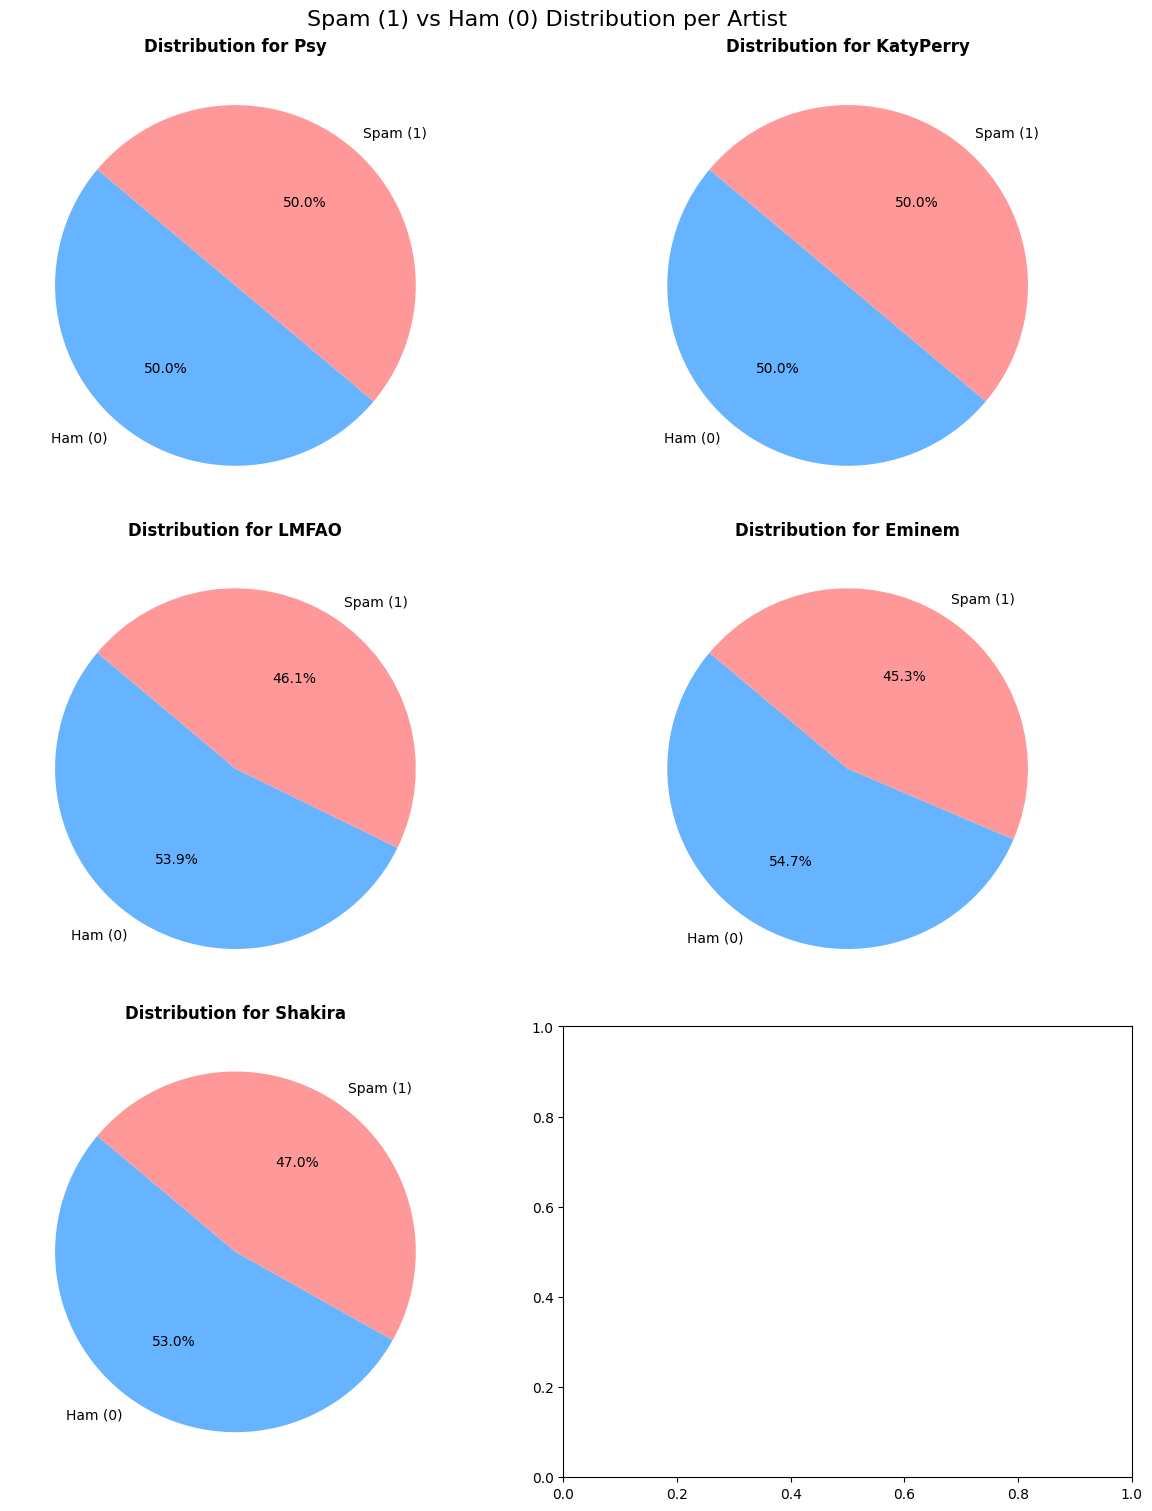

In [105]:
fig, ax = plt.subplots(3, 2, figsize=(12, 15), constrained_layout=True)

# Use flatten() to make it easier to loop through ax instead of i//2, i%2
axes = ax.flatten()

for i, (celeb, df) in enumerate(datasets.items()):
    counts = df['CLASS'].value_counts()
    labels = ['Ham (0)', 'Spam (1)']
    
    axes[i].pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
    axes[i].set_title(f'Distribution for {celeb}', fontsize=12, fontweight='bold')

fig.suptitle('Spam (1) vs Ham (0) Distribution per Artist', fontsize=16)
plt.show()

In [106]:
for celeb, df in datasets.items():
    print(f"Overall class distribution for {celeb}:")
    print(df['CLASS'].value_counts())
    print(f'Percentage of spam comments: {df["CLASS"][df["CLASS"]==1].count() / df["CLASS"].count() * 100:.2f}%')
    print()

Overall class distribution for Psy:
CLASS
1    175
0    175
Name: count, dtype: int64
Percentage of spam comments: 50.00%

Overall class distribution for KatyPerry:
CLASS
1    175
0    175
Name: count, dtype: int64
Percentage of spam comments: 50.00%

Overall class distribution for LMFAO:
CLASS
1    236
0    202
Name: count, dtype: int64
Percentage of spam comments: 53.88%

Overall class distribution for Eminem:
CLASS
1    245
0    203
Name: count, dtype: int64
Percentage of spam comments: 54.69%

Overall class distribution for Shakira:
CLASS
0    196
1    174
Name: count, dtype: int64
Percentage of spam comments: 47.03%



### Dataset selection

In [107]:
available_artists = list(datasets.keys())
print(f"Available datasets: {available_artists}")

# Change this list if you only want to analyze specific artists
# For now, we select ALL to ensure the most robust analysis
selected_artists = ['Psy', 'KatyPerry', 'LMFAO', 'Eminem', 'Shakira']

# Filter our dictionary to keep only the selected ones
datasets_selected = {name: datasets[name] for name in selected_artists}

print(f"Proceeding with {len(datasets_selected)} datasets.")

Available datasets: ['Psy', 'KatyPerry', 'LMFAO', 'Eminem', 'Shakira']
Proceeding with 5 datasets.


### Combining selected dataset

In [108]:
# Combine selected datasets into a single 'Master' DataFrame for EDA
# We add a 'SOURCE' column so we know which artist the comment came from
df_all = pd.concat(
    [df.assign(SOURCE=name) for name, df in datasets_selected.items()], 
    ignore_index=True
)

# Clean up: We only need the text, the class, and the source artist
df_all = df_all[['CONTENT', 'CLASS', 'SOURCE']]
df_all.rename(columns={'SOURCE':'ARTIST'}, inplace=True)

print(f"Data combined into a single DataFrame with shape: {df_all.shape}")
df_all.sample(5)

Data combined into a single DataFrame with shape: (1956, 3)


,CONTENT,CLASS,ARTIST
1304,sorry but eminmem is a worthless wife beating ...,0,Eminem
869,Check out this video on YouTube:﻿,1,LMFAO
1344,Rihanna is so beautiful and amazing ♥♥♥♥♥love ...,0,Eminem
298,https://www.facebook.com/SchoolGeniusNITS/phot...,1,Psy
871,Thumbs up if you&#39;re watching in 2015﻿,0,LMFAO


In [109]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1956 entries, 0 to 1955
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   CONTENT  1956 non-null   object
 1   CLASS    1956 non-null   int64 
 2   ARTIST   1956 non-null   object
dtypes: int64(1), object(2)
memory usage: 46.0+ KB


In [110]:
df_all.shape

(1956, 3)

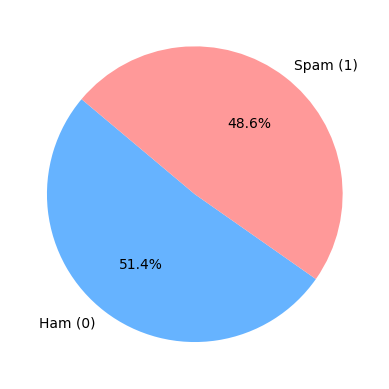

In [111]:
plt.pie(df_all['CLASS'].value_counts(), labels=['Ham (0)', 'Spam (1)'], autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.show()

In [112]:
df_all["num_chars"] = df_all["CONTENT"].apply(len)
df_all.sample(5)

,CONTENT,CLASS,ARTIST,num_chars
77,WHATS UP EVERYONE!? :-) I Trying To Showcase M...,1,Psy,243
849,Thumbs up if FE-FE-FE-FE-FEGELEIN brought u here﻿,1,LMFAO,49
707,This song is just really fun ﻿,0,LMFAO,30
1823,I love you,0,Shakira,10
898,I like it<br />﻿,0,LMFAO,16


In [113]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\koksl\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [114]:
# Calculate number of words in each comment by using word tokenization
df_all["num_words"] = df_all["CONTENT"].apply(lambda x: len(nltk.word_tokenize(x))) 
df_all.sample(5)

,CONTENT,CLASS,ARTIST,num_chars,num_words
958,Check out this video on YouTube:﻿,1,LMFAO,33,8
1008,Please become my first subscriber. Thank you.﻿,1,LMFAO,47,8
930,Check out this video on YouTube:﻿,1,LMFAO,33,8
1654,waka waka﻿,0,Shakira,10,2
924,Check out this video on YouTube:﻿,1,LMFAO,33,8


In [115]:
df_all["num_sentences"] = df_all["CONTENT"].apply(lambda x: len(nltk.sent_tokenize(x)))
df_all.sample(5)

,CONTENT,CLASS,ARTIST,num_chars,num_words,num_sentences
1912,CHECK OUT partyman318 FR GOOD TUNEZ!! :D,1,Shakira,40,10,2
753,cool﻿,0,LMFAO,5,1,1
938,Check out this playlist on YouTube:<br /><br />﻿,1,LMFAO,48,16,1
511,Please look at my channel﻿,1,KatyPerry,26,5,1
484,"Since she is a feminist champion, why would sh...",0,KatyPerry,184,35,1


In [116]:
df_all.describe()

,CLASS,num_chars,num_words,num_sentences
count,1956.000000,1956.000000,1956.000000,1956.000000
mean,0.513804,94.700920,21.212679,1.810838
std,0.499937,128.222062,32.558659,2.098350
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,29.000000,6.000000,1.000000
50%,1.000000,48.000000,10.000000,1.000000
75%,1.000000,97.000000,21.000000,2.000000
max,1.000000,1200.000000,697.000000,25.000000


In [117]:
print("Statistics for Spam (CLASS=1) comments:")
df_all[df_all['CLASS'] == 1].describe()

Statistics for Spam (CLASS=1) comments:


,CLASS,num_chars,num_words,num_sentences
count,1005.0,1005.000000,1005.000000,1005.000000
mean,1.0,137.336318,29.842786,2.215920
std,0.0,158.977404,41.278222,2.731356
min,1.0,10.000000,1.000000,1.000000
25%,1.0,36.000000,8.000000,1.000000
50%,1.0,65.000000,13.000000,1.000000
75%,1.0,171.000000,37.000000,2.000000
max,1.0,1200.000000,697.000000,25.000000


In [118]:
print("Statistics for Ham (CLASS=0) comments:")
df_all[df_all['CLASS'] == 0].describe()

Statistics for Ham (CLASS=0) comments:


,CLASS,num_chars,num_words,num_sentences
count,951.0,951.000000,951.000000,951.000000
mean,0.0,49.644585,12.092534,1.382755
std,0.0,56.284782,14.788682,0.905351
min,0.0,2.000000,1.000000,1.000000
25%,0.0,18.000000,4.000000,1.000000
50%,0.0,34.000000,8.000000,1.000000
75%,0.0,62.000000,15.000000,2.000000
max,0.0,753.000000,193.000000,12.000000


In [119]:
empty_char = len(df_all[df_all["num_chars"] == 0])
print(f"Number of comments with zero characters: {empty_char}")

Number of comments with zero characters: 0


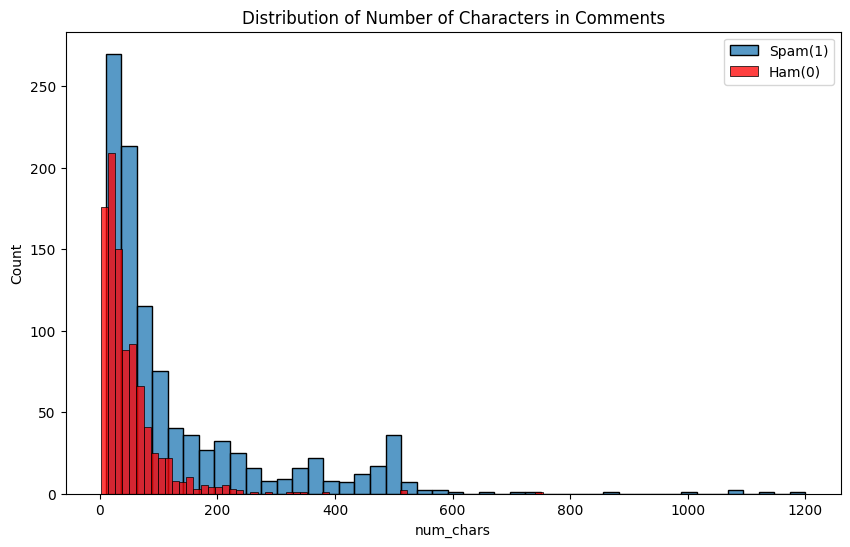

In [120]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_all[df_all["CLASS"]==1]["num_chars"], label="Spam(1)")
sns.histplot(data=df_all[df_all["CLASS"]==0]["num_chars"], color='red', label="Ham(0)")
plt.title("Distribution of Number of Characters in Comments")
plt.legend()
plt.show()

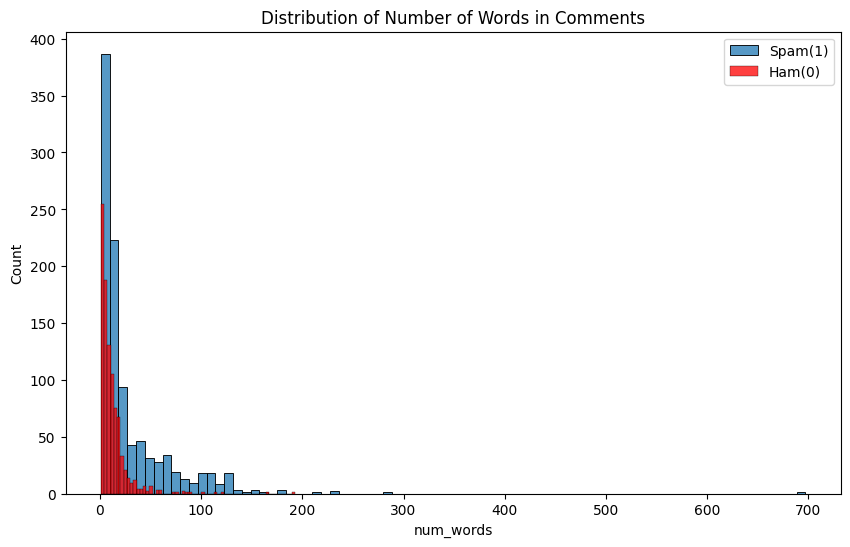

In [121]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_all[df_all["CLASS"]==1]["num_words"], label="Spam(1)", bins=80)
sns.histplot(data=df_all[df_all["CLASS"]==0]["num_words"], color='red', label="Ham(0)", bins=60)
plt.title("Distribution of Number of Words in Comments")
plt.legend()
plt.show()

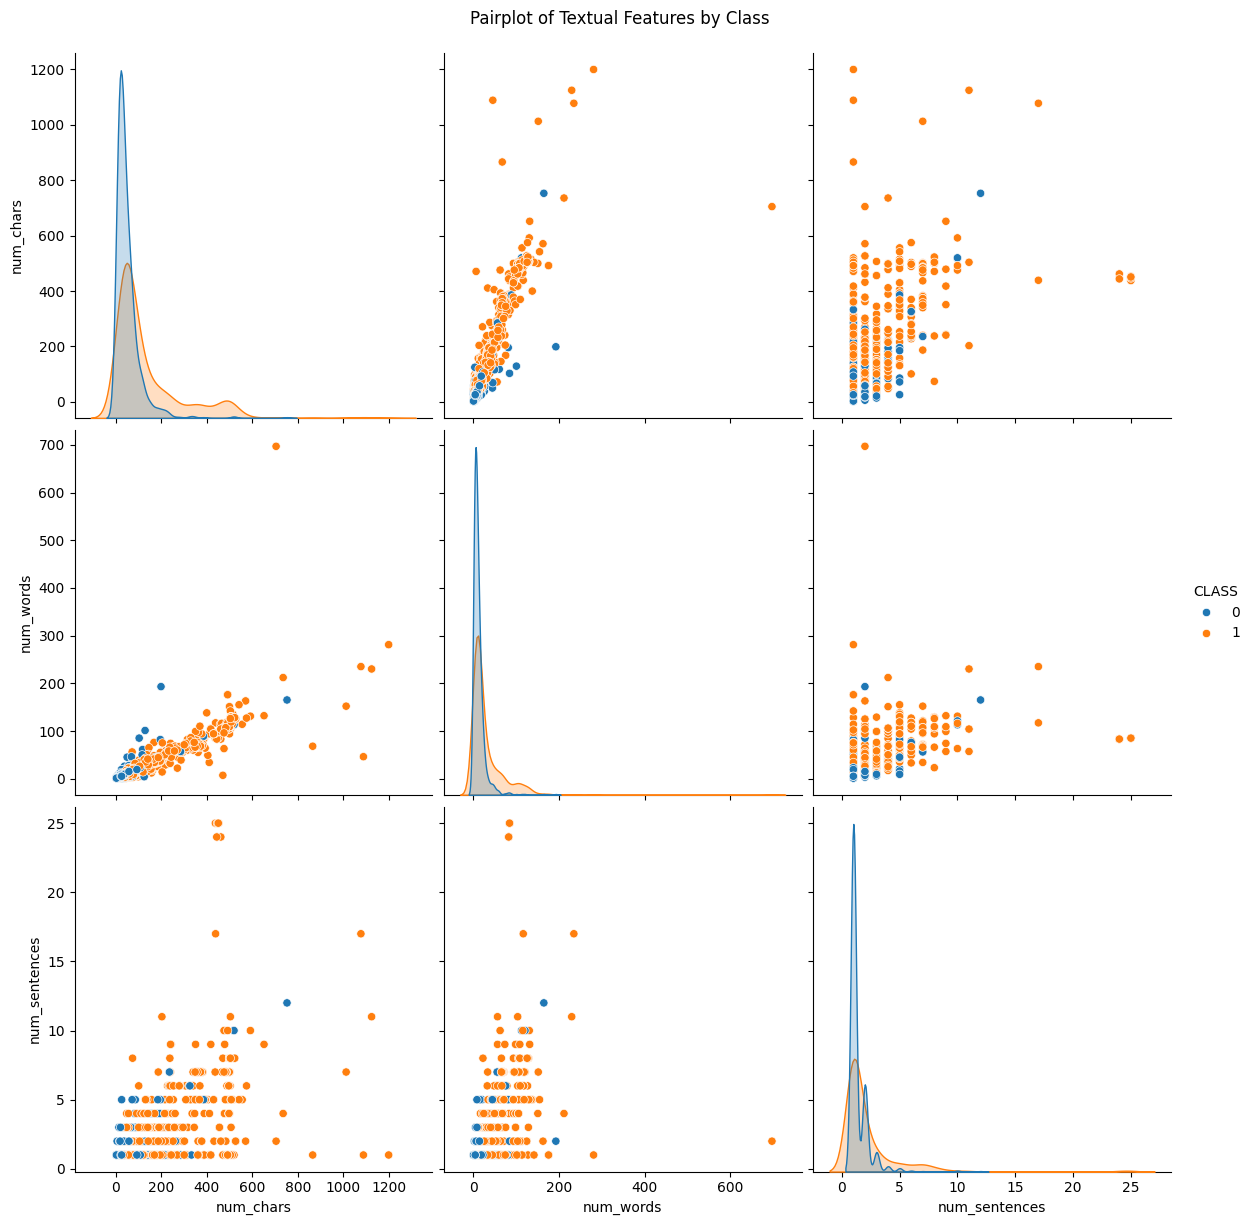

In [122]:
sns.pairplot(data=df_all, hue="CLASS", vars=["num_chars", "num_words", "num_sentences"], height=4)
plt.suptitle("Pairplot of Textual Features by Class", y=1.02)
plt.show()

<Axes: >

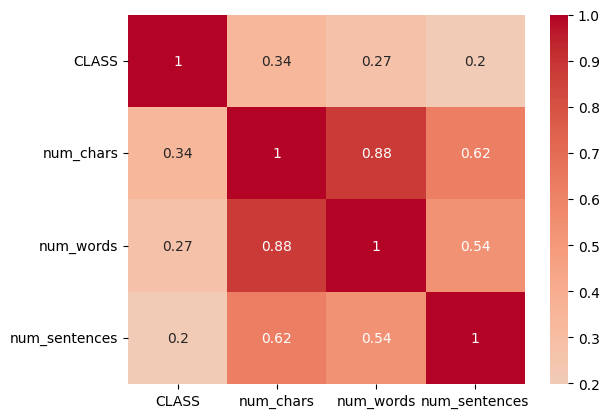

In [123]:
sns.heatmap(df_all.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)

### Data Preprocessing
- lower case
- tokenization
- removing special characters
- removing stop words
- stemming

In [124]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

# 1. Download the stopwords resource
nltk.download('stopwords')

# 2. Get the list of English stop words
stop_words = stopwords.words('english')

string.punctuation

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\koksl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [125]:
def transform_text(text):
    # Lowercase
    text = text.lower()
    text = nltk.word_tokenize(text)
    remove_special_characters = [char for char in text if char.isalnum()]
    text = remove_special_characters[:]
    remove_special_characters.clear()
    remove_special_characters = [word for word in text if word not in stopwords.words('english') and word not in string.punctuation]

    text = remove_special_characters[:]
    remove_special_characters.clear()
    remove_special_characters = [ps.stem(word) for word in text]

    return ' '.join(remove_special_characters)


In [126]:

df_all["Transformed_TEXT"] = df_all["CONTENT"].apply(transform_text)
df_all.sample(5)

,CONTENT,CLASS,ARTIST,num_chars,num_words,num_sentences,Transformed_TEXT
1315,Who is watching in 2015 like﻿,0,Eminem,29,6,1,watch 2015
42,SUBSCRIBE TO ME AND I'LL SUBSCRIBE TO YOU! (Mu...,1,Psy,70,17,2,subscrib subscrib must like czfcxsn0jnq
223,Can anyone sub to my channel? :D﻿,1,Psy,33,9,2,anyon sub channel
171,http://flipagram.com/f/LUkA1QMrhF﻿,1,Psy,34,3,1,http
1136,HOW MANY THUMBS UP FOR LOUIS SAVING THE DAY!?!?﻿,1,LMFAO,48,14,2,mani thumb loui save day


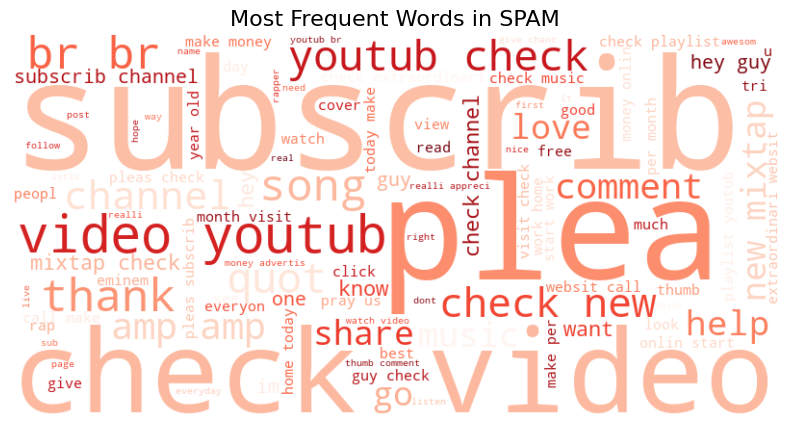

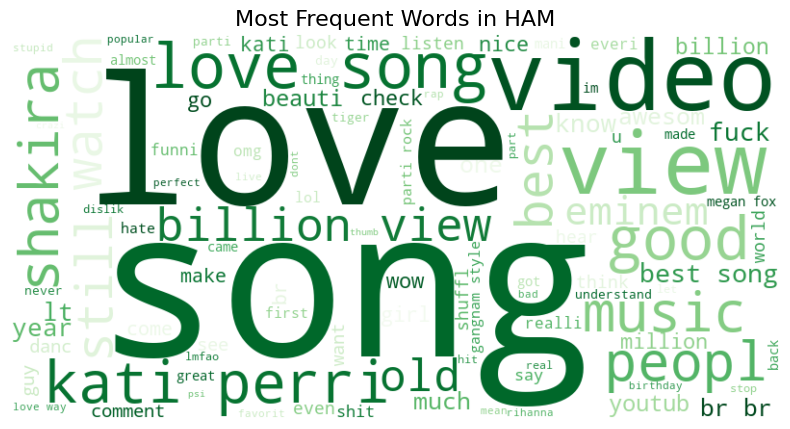

In [127]:
# Split the data into two strings
spam_words = ' '.join(df_all[df_all['CLASS'] == 1]['Transformed_TEXT'])
ham_words = ' '.join(df_all[df_all['CLASS'] == 0]['Transformed_TEXT'])

# Function to generate word clouds
def create_cloud(text, title, color):
    wc = WordCloud(width=800, height=400, background_color='white', colormap=color, max_words=100).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

create_cloud(spam_words, "Most Frequent Words in SPAM", "Reds")
create_cloud(ham_words, "Most Frequent Words in HAM", "Greens")

Total words in SPAM corpus: 12149
Most common words in SPAM corpus:


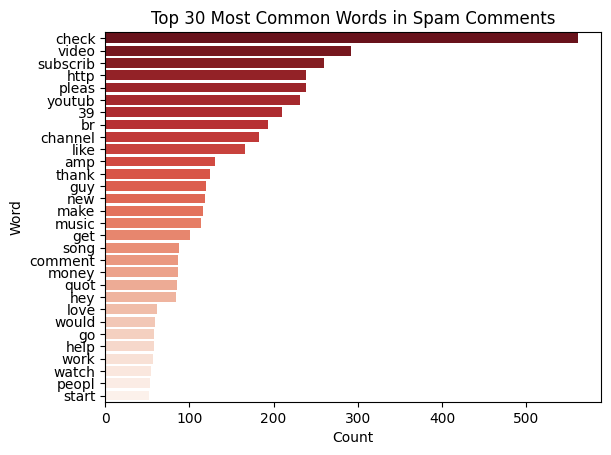

Total words in HAM corpus: 4397
Most common words in HAM corpus:


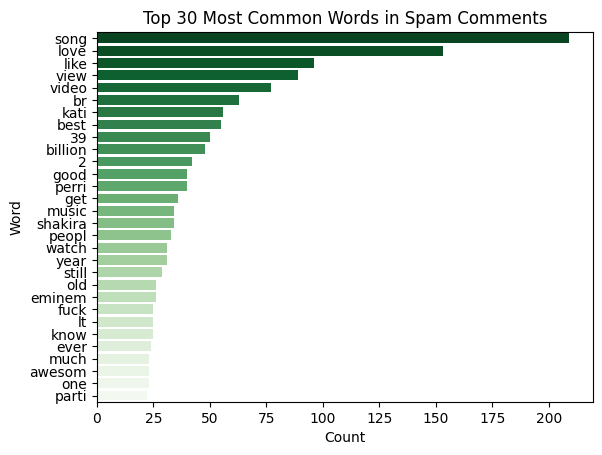

In [128]:
def top_n_words(df, label, n=30):
    corpus = []
    for msg in df[df['CLASS'] == label]['Transformed_TEXT'].tolist():
        for word in msg.split():
            corpus.append(word)
    most_common_words = Counter(corpus).most_common(n)
    print(f"Total words in {'SPAM' if label == 1 else 'HAM'} corpus: {len(corpus)}")
    return most_common_words

def plot_top_n_words(most_common_words, label, palette="Reds_r"):
    print("Most common words in {} corpus:".format("SPAM" if label == 1 else "HAM"))
    # most_common_words looks like: [('word1', count1), ('word2', count2)...]
    df_plot = pd.DataFrame(most_common_words, columns=['Word', 'Count'])
    sns.barplot(x=df_plot['Count'], y=df_plot['Word'], palette=palette)
    plt.title("Top 30 Most Common Words in Spam Comments")
    plt.show()


top_spam_words = top_n_words(df_all, label=1, n=30)
plot_top_n_words(top_spam_words, label=1, palette="Reds_r")

top_ham_words = top_n_words(df_all, label=0, n=30)
plot_top_n_words(top_ham_words, label=0, palette="Greens_r")

### Model Building

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(cv.fit_transform(df_all['Transformed_TEXT']).toarray())

cv = CountVectorizer()
tfidf = TfidfVectorizer()

df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

train_df = df_all[df_all["ARTIST"] != 'KatyPerry']
test_df = df_all[df_all["ARTIST"] == 'KatyPerry']


X_train = cv.fit_transform(train_df['Transformed_TEXT']).toarray()
y_train = train_df['CLASS'].values

X_test = cv.transform(test_df['Transformed_TEXT']).toarray()
y_test = test_df['CLASS'].values

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 1606, Test size: 350


In [134]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = [XGBClassifier(use_label_encoder=False, eval_metric='logloss'), LGBMClassifier(), LogisticRegression(max_iter=1000), SVC(kernel='linear'), RandomForestClassifier(n_estimators=100), KNeighborsClassifier()]
for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Mode: {model}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print()

Mode: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)
Accuracy: 0.9285714285714286
Confusion Matrix:
 [[164  11]
 [ 14 161]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       175
          

In [136]:
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

train_df = df_all[df_all["ARTIST"] != 'KatyPerry']
test_df = df_all[df_all["ARTIST"] == 'KatyPerry']

X_train_t = tfidf.fit_transform(train_df['Transformed_TEXT']).toarray()
y_train_ = train_df['CLASS'].values

X_test_t = tfidf.transform(test_df['Transformed_TEXT']).toarray()
y_test = test_df['CLASS'].values

print(f"Train size: {X_train_t.shape[0]}, Test size: {X_test_t.shape[0]}")

Train size: 1606, Test size: 350


In [137]:
models = [XGBClassifier(use_label_encoder=False, eval_metric='logloss'), LGBMClassifier(), LogisticRegression(max_iter=1000), SVC(kernel='linear'), RandomForestClassifier(n_estimators=100), KNeighborsClassifier()]
for model in models:
    model.fit(X_train_t, y_train)
    y_pred_t = model.predict(X_test_t)
    print(f"Mode: {model}")
    print("Accuracy:", accuracy_score(y_test, y_pred_t))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_t))
    print("Classification Report:\n", classification_report(y_test, y_pred_t))
    print()

Mode: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)
Accuracy: 0.4542857142857143
Confusion Matrix:
 [[ 61 114]
 [ 77  98]]
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.35      0.39       175
          

In [138]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


cv = CountVectorizer()
tfidf = TfidfVectorizer()

df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

train_df = df_all[df_all["ARTIST"] != 'KatyPerry']
test_df = df_all[df_all["ARTIST"] == 'KatyPerry']

X_train = scaler.fit_transform(cv.fit_transform(train_df['Transformed_TEXT']).toarray())
y_train = train_df['CLASS'].values

X_test = scaler.transform(cv.transform(test_df['Transformed_TEXT']).toarray())
y_test = test_df['CLASS'].values

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 1606, Test size: 350


In [139]:
models = [XGBClassifier(use_label_encoder=False, eval_metric='logloss'), LGBMClassifier(), LogisticRegression(max_iter=1000), SVC(kernel='linear'), RandomForestClassifier(n_estimators=100), KNeighborsClassifier()]
for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Mode: {model}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print()

Mode: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)
Accuracy: 0.9285714285714286
Confusion Matrix:
 [[164  11]
 [ 14 161]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       175
          